In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
df = pd.read_csv("/content/sleep_health_dataset.csv")

In [40]:
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [41]:
df.sample(5)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
95242,95243,21,Female,Sales,35.7,Canada,5.38,3.6,18.8,23.1,...,70,1,0,23.1,1.08,Autumn,Weekday,62.0,Moderate,0
41283,41284,24,Male,Nurse,27.7,USA,6.58,5.7,22.3,27.2,...,73,1,0,21.5,-0.14,Winter,Weekday,76.3,Healthy,0
13587,13588,23,Female,Freelancer,23.9,UK,6.91,6.2,24.2,19.7,...,66,1,0,23.2,0.42,Autumn,Weekday,85.6,Healthy,1
97607,97608,30,Male,Retired,23.7,France,9.68,4.9,20.4,25.8,...,68,0,0,24.3,1.32,Autumn,Weekend,51.3,Mild,1
48,49,35,Male,Driver,27.4,Spain,5.99,1.5,24.1,21.3,...,68,1,1,23.9,0.50,Autumn,Weekday,30.2,Moderate,0


In [42]:
df.shape

(100000, 32)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [44]:
df.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='object')

In [45]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [46]:
df.nunique()


,0
person_id,100000
age,52
gender,3
occupation,12
bmi,277
country,15
sleep_duration_hrs,750
sleep_quality_score,89
rem_percentage,201
deep_sleep_percentage,251


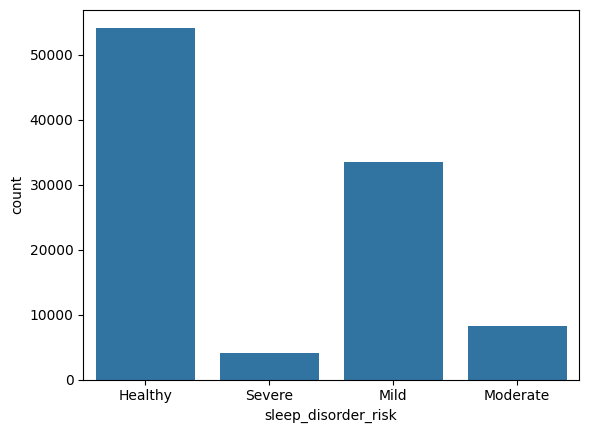

In [47]:
df['sleep_disorder_risk'].value_counts()
sns.countplot(x='sleep_disorder_risk', data=df)
plt.show()

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [50]:
df.isnull().sum()


,0
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0


In [51]:
df.dtypes

,0
person_id,int64
age,int64
gender,object
occupation,object
bmi,float64
country,object
sleep_duration_hrs,float64
sleep_quality_score,float64
rem_percentage,float64
deep_sleep_percentage,float64


In [52]:
df.drop('person_id', axis=1, inplace=True)

In [53]:
df.apply(pd.Series.unique)


,0
age,"[29, 55, 42, 37, 23, 20, 48, 41, 18, 58, 46, 2..."
gender,"[Female, Male, Other]"
occupation,"[Driver, Software Engineer, Nurse, Student, La..."
bmi,"[25.7, 22.0, 25.0, 29.5, 23.6, 25.5, 18.2, 31...."
country,"[Japan, USA, India, Spain, Brazil, Netherlands..."
sleep_duration_hrs,"[6.19, 8.32, 3.74, 6.79, 5.02, 8.16, 7.27, 8.0..."
sleep_quality_score,"[6.6, 6.9, 1.0, 6.4, 3.2, 5.7, 5.1, 6.5, 5.4, ..."
rem_percentage,"[22.5, 26.9, 20.2, 17.7, 23.3, 17.3, 17.5, 25...."
deep_sleep_percentage,"[19.3, 14.9, 16.2, 17.7, 18.3, 20.1, 18.8, 22...."
sleep_latency_mins,"[16, 17, 26, 13, 30, 29, 31, 22, 37, 24, 20, 1..."


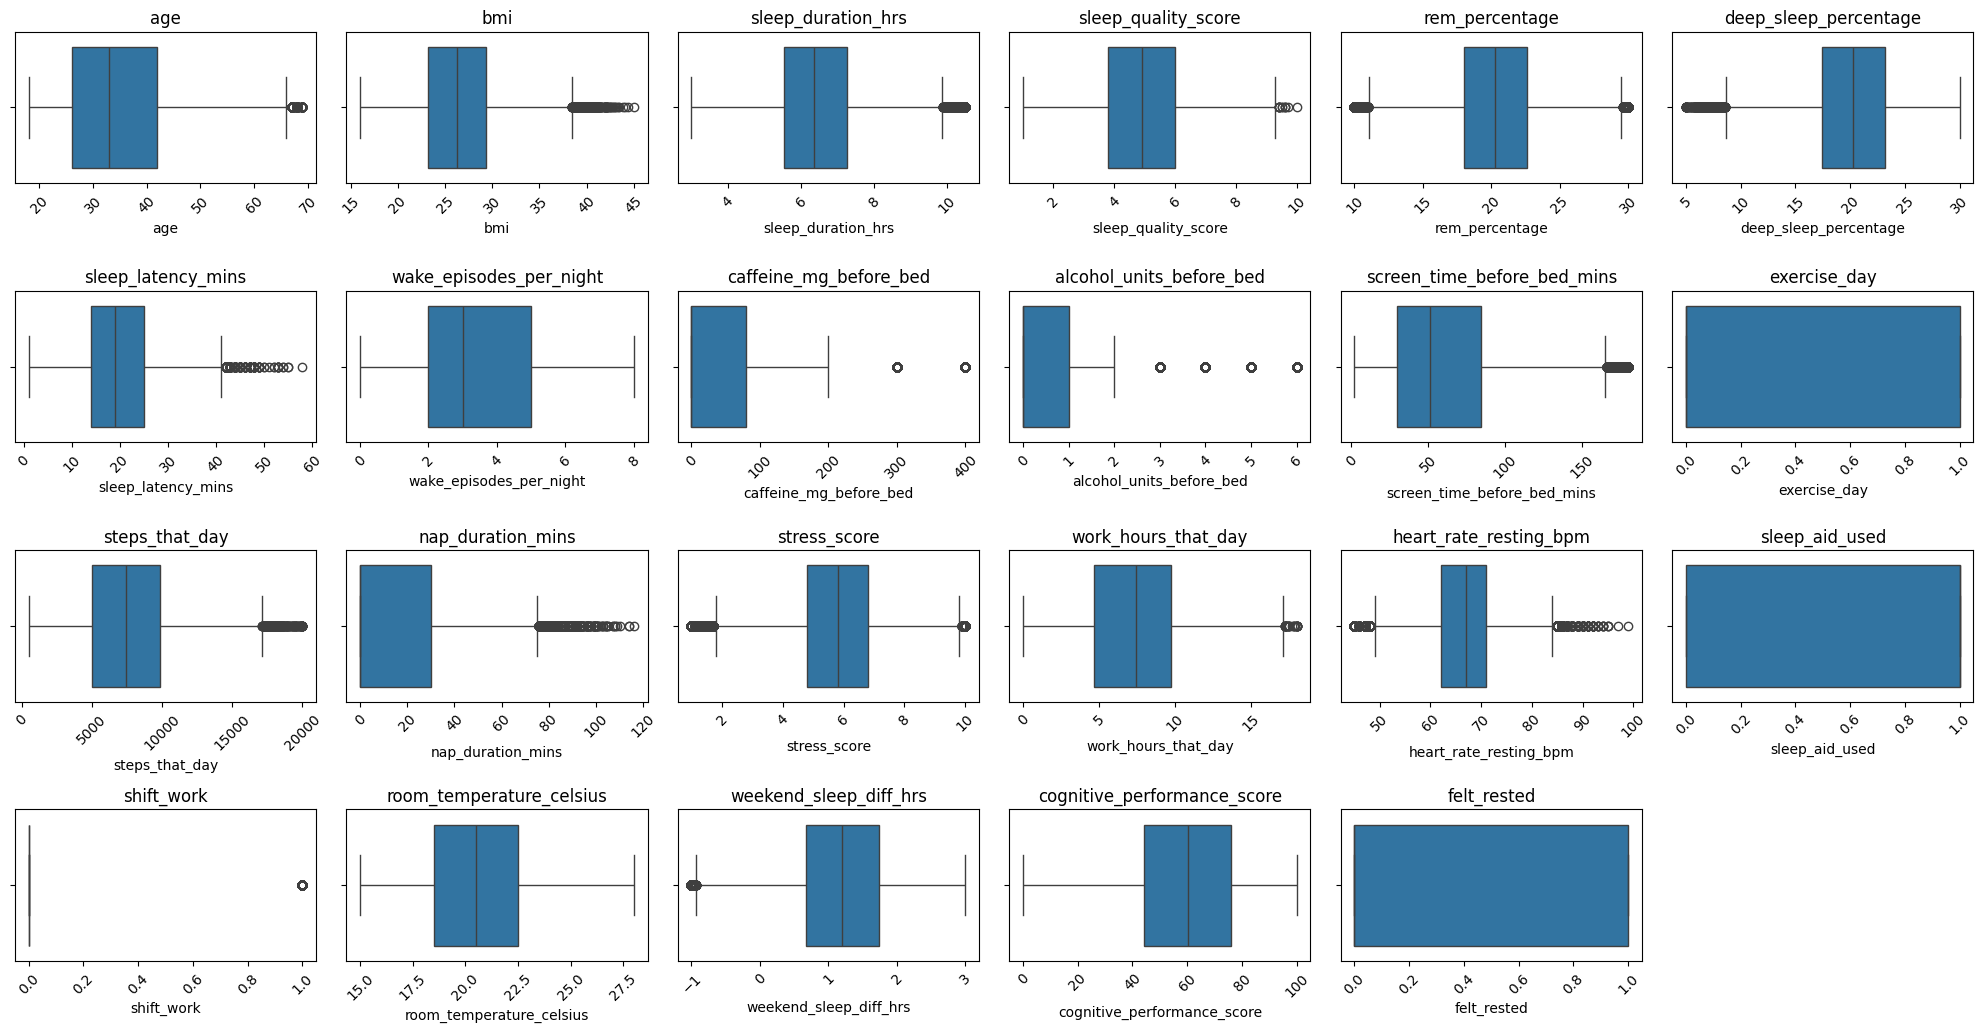

In [54]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20,15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 6, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

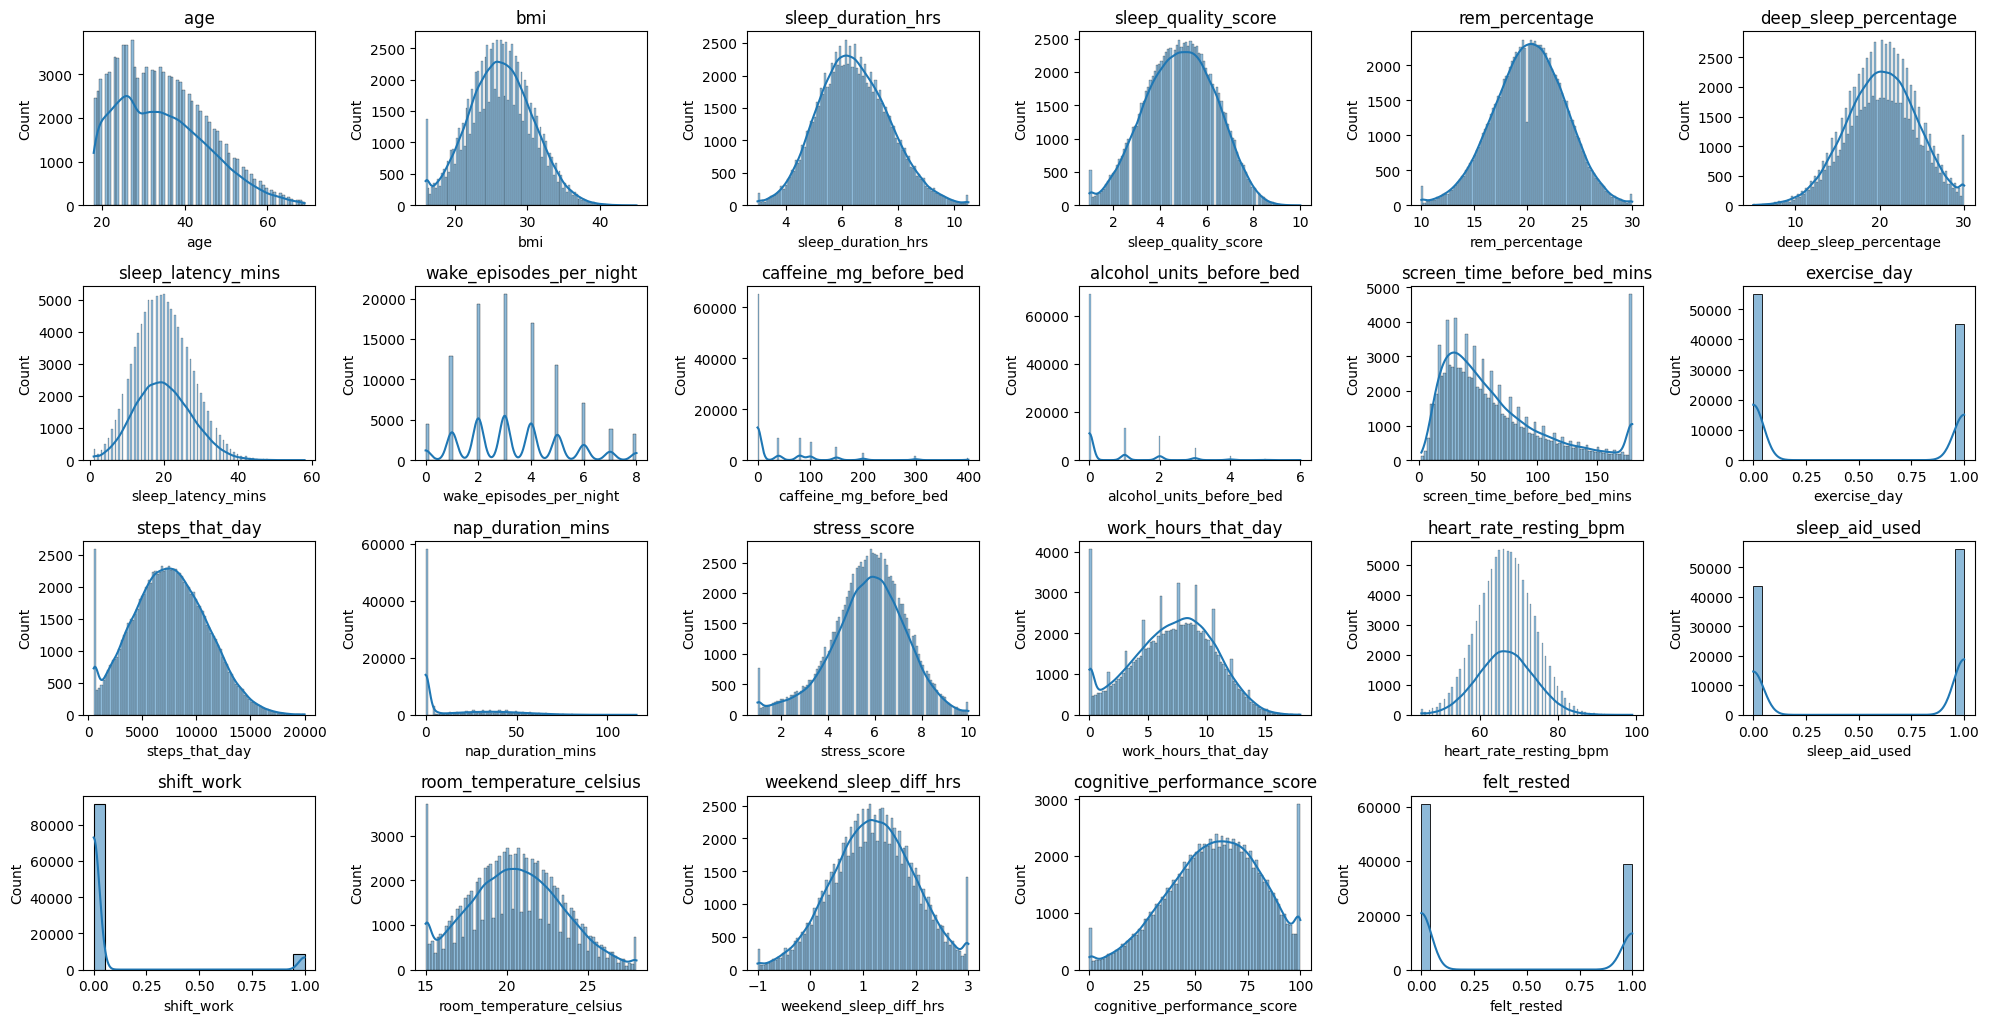

In [55]:


plt.figure(figsize=(20,15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 6, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [56]:
cat_cols = df.select_dtypes(include='object').columns


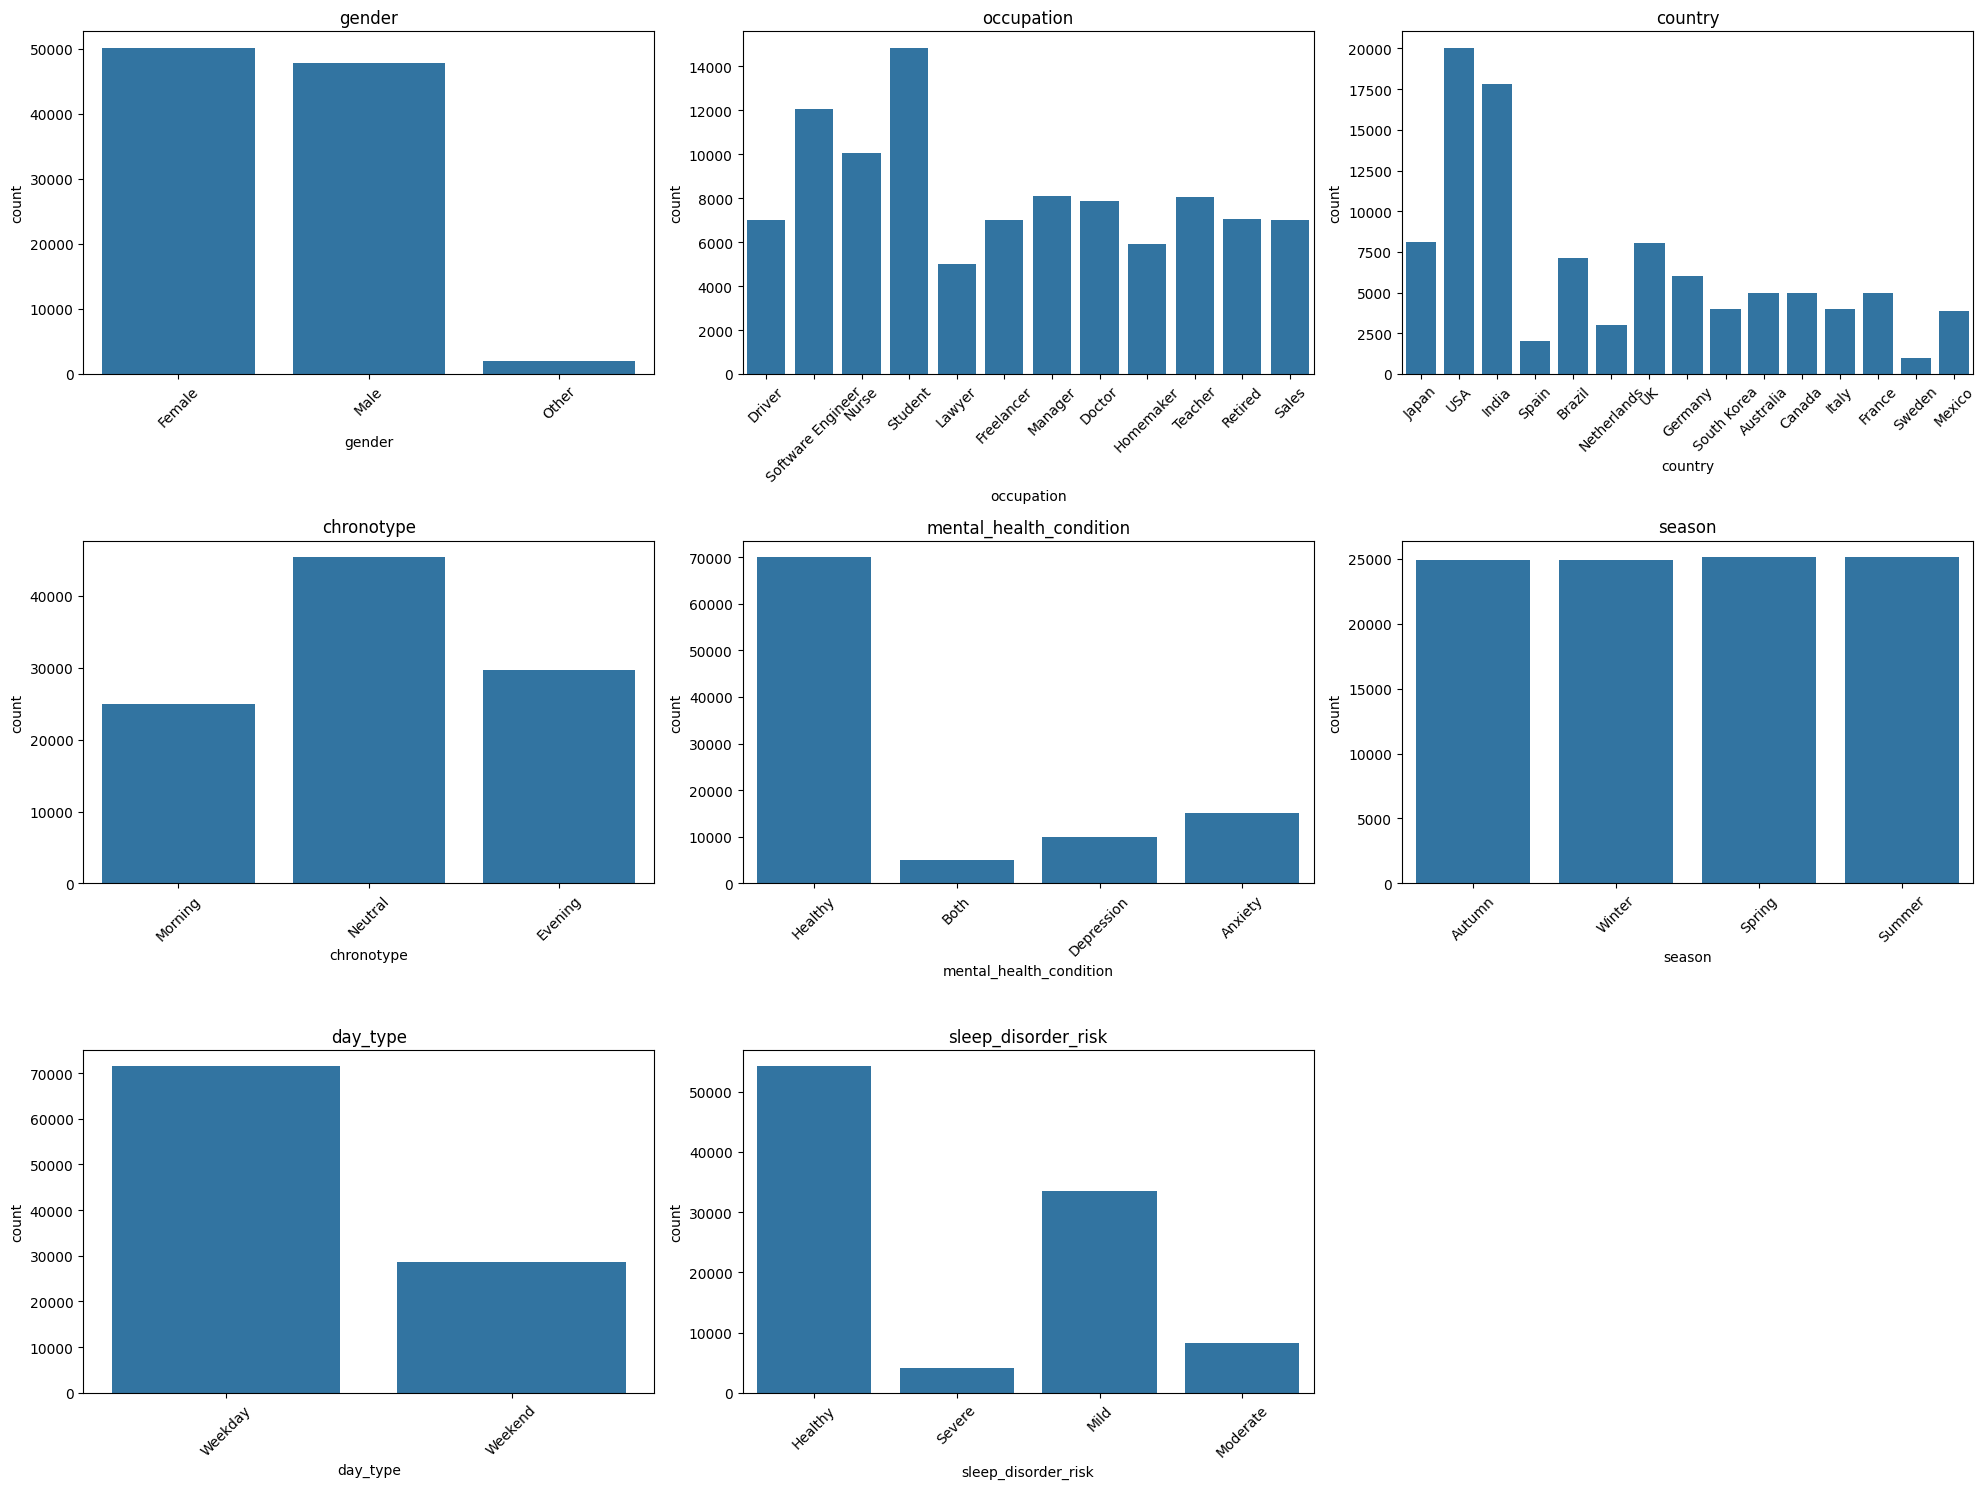

In [57]:

plt.figure(figsize=(20,15))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [58]:
skewness = df.skew(numeric_only=True)
kurtosis = df.kurtosis(numeric_only=True)

print("Skewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)

Skewness:
 age                            0.549902
bmi                            0.071914
sleep_duration_hrs             0.216783
sleep_quality_score           -0.091709
rem_percentage                -0.113301
deep_sleep_percentage         -0.108602
sleep_latency_mins             0.242292
wake_episodes_per_night        0.454924
caffeine_mg_before_bed         2.384080
alcohol_units_before_bed       1.927083
screen_time_before_bed_mins    1.152855
exercise_day                   0.198128
steps_that_day                 0.135000
nap_duration_mins              1.205569
stress_score                  -0.363788
work_hours_that_day           -0.161502
heart_rate_resting_bpm         0.005647
sleep_aid_used                -0.248336
shift_work                     2.989650
room_temperature_celsius       0.128792
weekend_sleep_diff_hrs        -0.052748
cognitive_performance_score   -0.289882
felt_rested                    0.450541
dtype: float64

Kurtosis:
 age                           -0.355247
bm

In [59]:
skewed_cols = [
    'caffeine_mg_before_bed',
    'alcohol_units_before_bed',
    'screen_time_before_bed_mins',
    'nap_duration_mins'
]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

<Axes: >

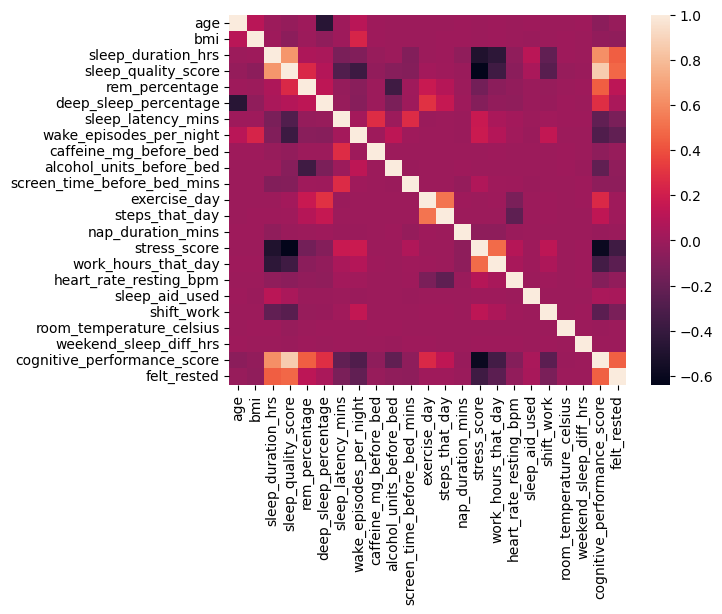

In [60]:
sns.heatmap(df.corr(numeric_only=True), annot=False)

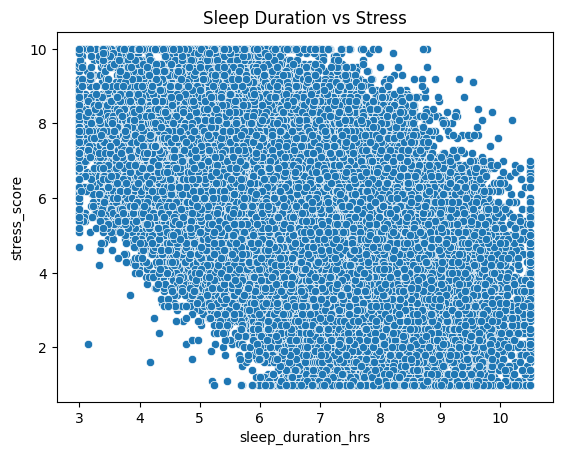

In [61]:
# Sleep vs Stress
sns.scatterplot(x='sleep_duration_hrs', y='stress_score', data=df)
plt.title("Sleep Duration vs Stress")
plt.show()

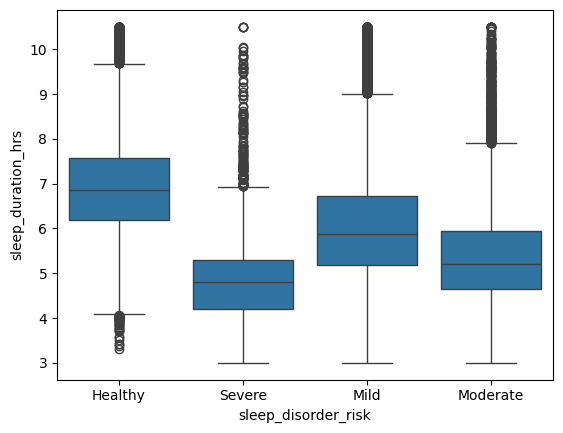

In [62]:
sns.boxplot(x='sleep_disorder_risk', y='sleep_duration_hrs', data=df)
plt.show()

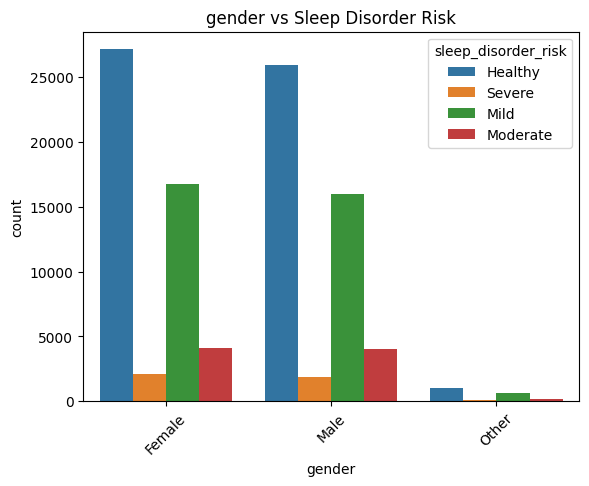

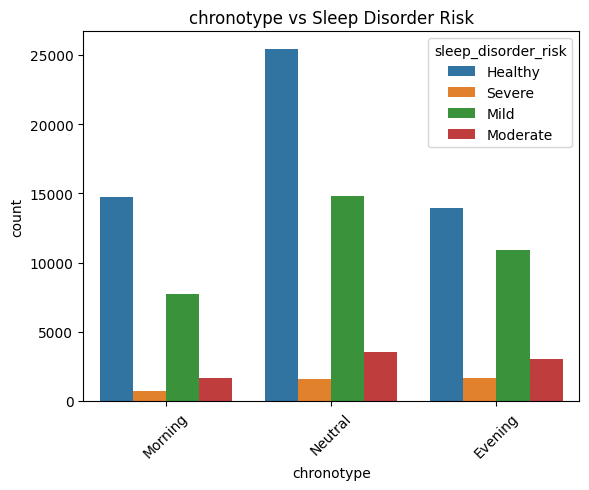

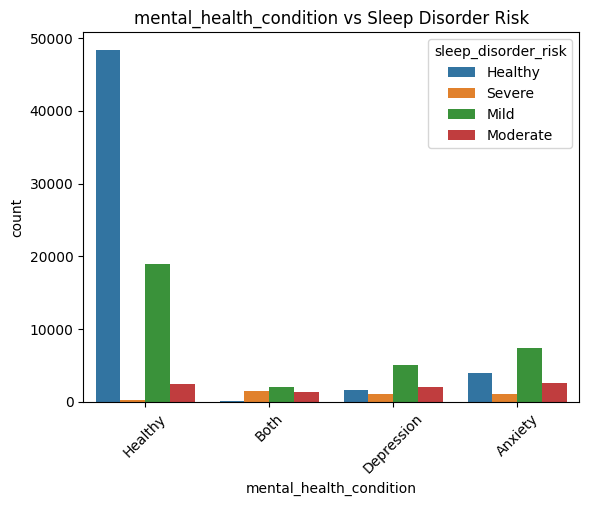

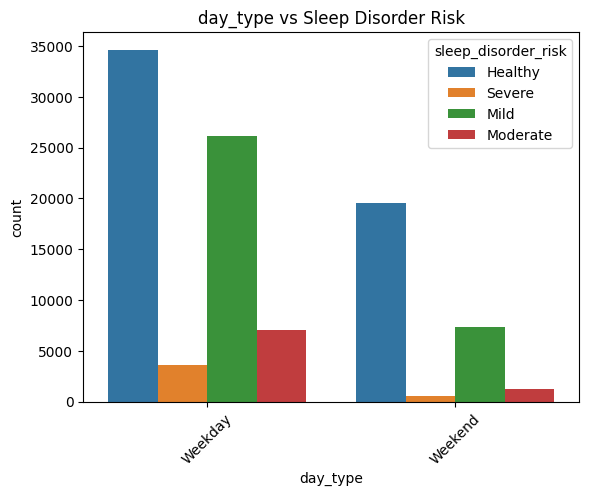

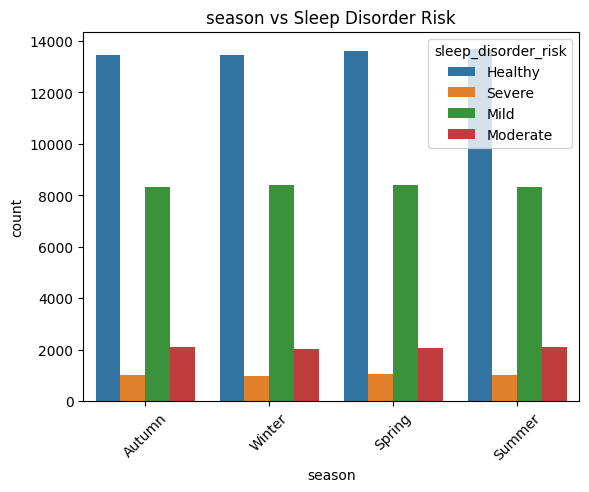

In [63]:
cols = ['gender', 'chronotype', 'mental_health_condition', 'day_type', 'season']

for col in cols:
    sns.countplot(x=col, hue='sleep_disorder_risk', data=df)
    plt.title(f"{col} vs Sleep Disorder Risk")
    plt.xticks(rotation=45)
    plt.show()

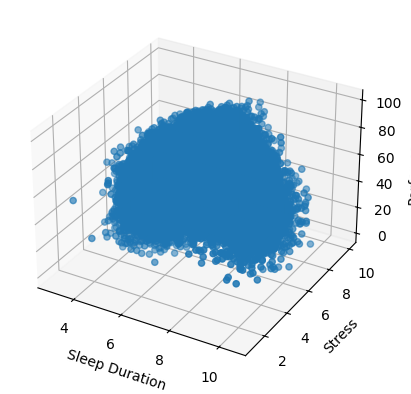

In [ ]:

fig = plt.figure()
ax = fig.add_subplot(131, projection='3d')

ax.scatter(
    df['sleep_duration_hrs'],
    df['stress_score'],
    df['cognitive_performance_score']
)

ax.set_xlabel('Sleep Duration')
ax.set_ylabel('Stress')
ax.set_zlabel('Performance')

plt.show()

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


X = df.select_dtypes(include=['int64', 'float64'])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data

,feature,VIF
0,age,13.484579
1,bmi,35.547364
2,sleep_duration_hrs,54.693745
3,sleep_quality_score,70.286437
4,rem_percentage,49.653819
5,deep_sleep_percentage,32.220125
6,sleep_latency_mins,10.159049
7,wake_episodes_per_night,5.485990
8,caffeine_mg_before_bed,1.668741
9,alcohol_units_before_bed,1.774393


In [66]:
#PCA


In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sleep_disorder_risk'] = le.fit_transform(df['sleep_disorder_risk'])

In [68]:
df = pd.get_dummies(df, columns=[
    'gender','occupation','country',
    'chronotype','mental_health_condition',
    'season','day_type'
], drop_first=True)

In [69]:
from sklearn.model_selection import train_test_split

X = df.drop('sleep_disorder_risk', axis=1)
y = df['sleep_disorder_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Classification


In [71]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [72]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.89445


In [73]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)


F1 Score: 0.8904859346359956


In [74]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)

roc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print("ROC-AUC:", roc)

ROC-AUC: 0.9820875703758328


In [75]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10863
           1       0.84      0.91      0.87      6585
           2       0.69      0.50      0.58      1706
           3       0.87      0.69      0.77       846

    accuracy                           0.89     20000
   macro avg       0.84      0.77      0.80     20000
weighted avg       0.89      0.89      0.89     20000



# Clustering

In [82]:
df_cluster = df.copy()

df_cluster.drop(['sleep_disorder_risk'], axis=1, inplace=True)

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

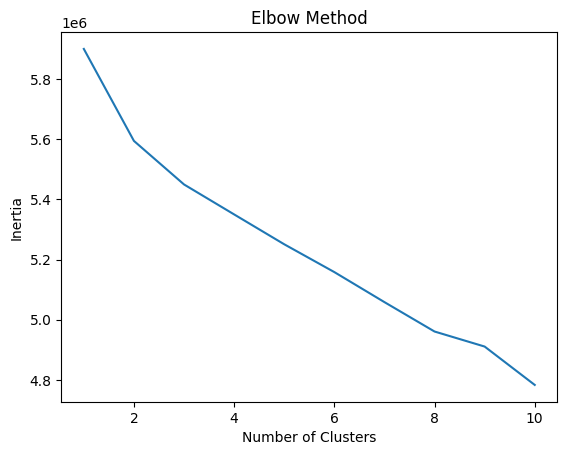

In [84]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [85]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

In [86]:
df.groupby('cluster').mean(numeric_only=True)

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,country_USA,chronotype_Morning,chronotype_Neutral,mental_health_condition_Both,mental_health_condition_Depression,mental_health_condition_Healthy,season_Spring,season_Summer,season_Winter,day_type_Weekend
cluster,,,,,,,,,,,,,,,,,,,,,
0,34.592000,26.304100,8.044593,6.637729,20.646443,20.561643,17.156429,2.716286,1.562127,0.323537,...,0.205857,0.249000,0.457143,0.045000,0.100143,0.707857,0.250000,0.254571,0.241857,0.292000
1,34.055896,26.031038,7.030137,5.922476,21.251490,20.991086,18.449586,2.865132,1.492092,0.250440,...,0.201779,0.267120,0.458956,0.002417,0.009370,0.873679,0.251096,0.250100,0.249751,0.468675
2,35.380747,26.550450,5.550378,3.914922,19.653656,19.537372,21.196333,3.881597,1.672943,0.376122,...,0.197271,0.234017,0.446479,0.000000,0.000000,0.760252,0.250095,0.250425,0.251617,0.103061
3,34.733165,26.289248,6.333291,3.617539,18.758040,19.990959,21.385966,3.542823,1.616381,0.330208,...,0.203363,0.243396,0.459335,0.342808,0.653099,0.000000,0.254632,0.255079,0.241089,0.272118


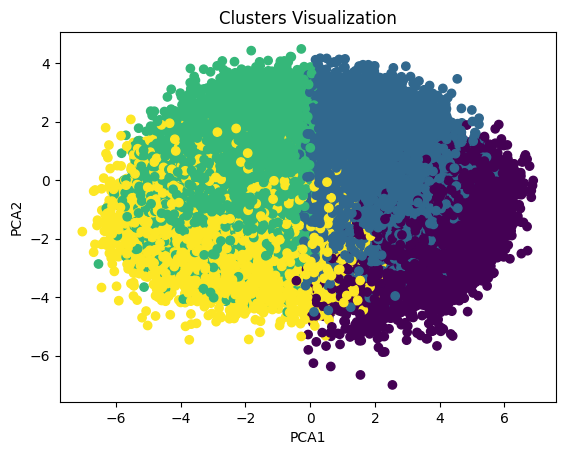

In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.scatter(components[:,0], components[:,1], c=clusters)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Clusters Visualization")
plt.show()